In [29]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score,accuracy_score

Load file and get description

In [30]:
df = pd.read_csv('bottles.csv')
df.describe()

,Unnamed: 0,Depthm,T_degC,Salnty,O2ml_L,STheta
count,1000.000000,1000.000000,987.000000,942.000000,799.000000,934.000000
mean,442944.925000,234.267000,10.811239,33.820019,3.374533,25.811728
std,258928.705981,345.483656,4.251855,0.569959,2.122412,1.020912
min,1085.000000,0.000000,1.520000,24.421770,0.011000,23.216000
25%,212630.250000,41.000000,7.520000,33.470250,1.175000,24.967250
50%,442519.000000,125.000000,10.140000,33.877000,3.443000,25.993500
75%,673027.500000,300.000000,13.965000,34.199750,5.485500,26.664000
max,894687.000000,4400.000000,24.180000,35.670000,7.270000,27.785000


DESCRIBE WHAT WAS DONE HERE

In [31]:
df.info()
df.dropna().info()
print(df.describe())
print()
print(df.dropna().describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   Depthm      1000 non-null   int64  
 2   T_degC      987 non-null    float64
 3   Salnty      942 non-null    float64
 4   O2ml_L      799 non-null    float64
 5   STheta      934 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 47.0 KB
<class 'pandas.core.frame.DataFrame'>
Index: 752 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  752 non-null    int64  
 1   Depthm      752 non-null    int64  
 2   T_degC      752 non-null    float64
 3   Salnty      752 non-null    float64
 4   O2ml_L      752 non-null    float64
 5   STheta      752 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 41.1 KB
          Unnamed: 0       Depthm     

Clean data
  - Fixed missing values by...

In [32]:
filled_null_values = df.fillna(df.mean())

# Search for outliers
Q1 = df["Salnty"].quantile(0.25)
Q3 = df["Salnty"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_salnty = df[(df["Salnty"] < lower) | (df["Salnty"] > upper)]
outliers_salnty

# Idendifying Depth Outliers
Q1 = df["Depthm"].quantile(0.25)
Q3 = df["Depthm"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_depth = df[(df["Depthm"] < lower) | (df["Depthm"] > upper)]
outliers_depth

Q1 = df["O2ml_L"].quantile(0.25)
Q3 = df["O2ml_L"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_O2ml_L = df[(df["O2ml_L"] < lower) | (df["O2ml_L"] > upper)]
outliers_O2ml_L

# Idendity Salinity Outliers
Q1 = df["Salnty"].quantile(0.25)
Q3 = df["Salnty"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_salnty = df[(df["Salnty"] < lower) | (df["Salnty"] > upper)]
outliers_salnty

,Unnamed: 0,Depthm,T_degC,Salnty,O2ml_L,STheta
146,668842,11,15.150,31.61900,5.700,23.33600
157,55504,20,17.770,32.29800,5.770,23.26100
200,894687,0,17.322,24.42177,7.165,24.42177
500,474872,10,16.770,35.67000,NaN,26.08500


Visualizations

<Axes: xlabel='Depthm', ylabel='Salnty'>

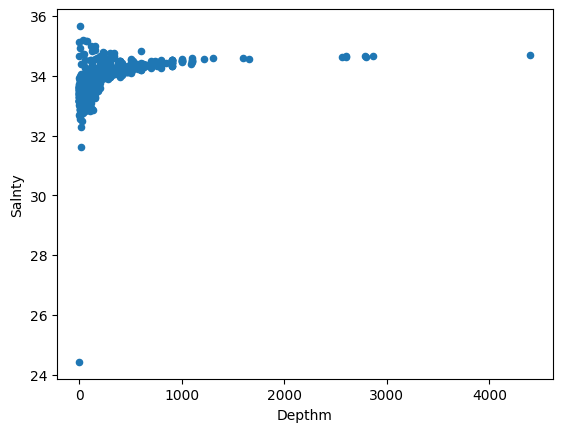

In [33]:
df.plot.scatter(x="Depthm", y="Salnty")


<Axes: xlabel='Salnty', ylabel='Depthm'>

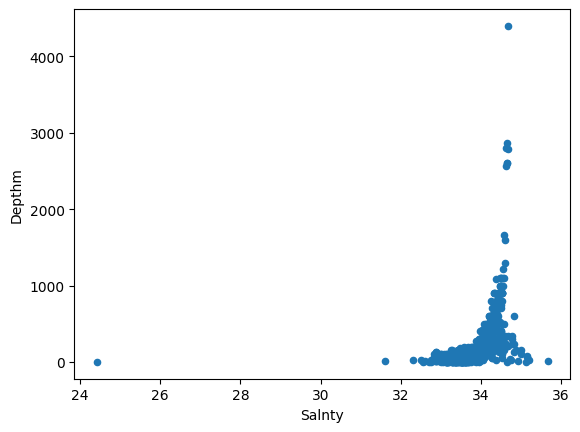

In [34]:
df.plot.scatter(x="Salnty", y="Depthm")

<Axes: xlabel='T_degC', ylabel='Salnty'>

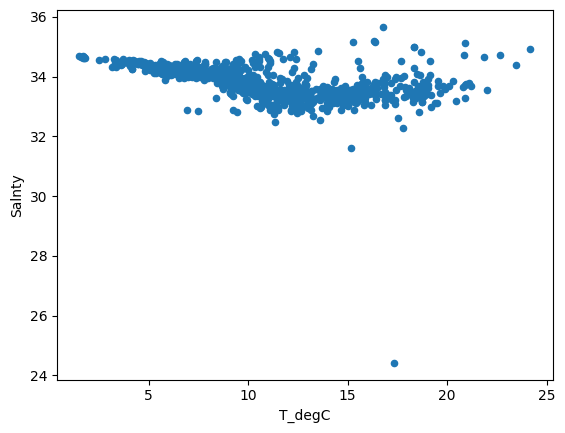

In [35]:
df.plot.scatter(x="T_degC", y="Salnty")

<Axes: xlabel='Salnty', ylabel='T_degC'>

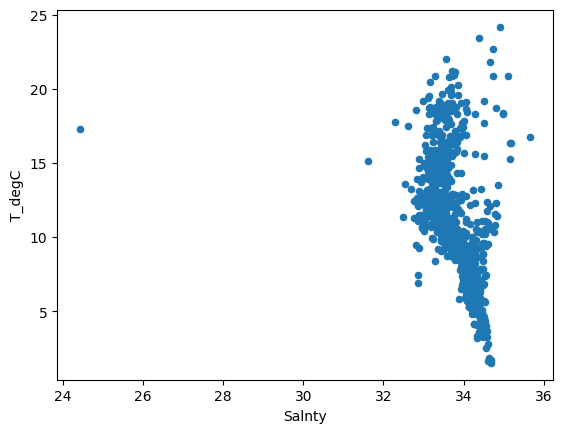

In [36]:
df.plot.scatter(x="Salnty", y="T_degC")

Correlation analysis

            Unnamed: 0    Depthm    T_degC    Salnty    O2ml_L    STheta
Unnamed: 0    1.000000 -0.126482  0.057986 -0.176952  0.101332 -0.076848
Depthm       -0.126482  1.000000 -0.667003  0.479382 -0.561984  0.652908
T_degC        0.057986 -0.667003  1.000000 -0.482814  0.809573 -0.960309
Salnty       -0.176952  0.479382 -0.482814  1.000000 -0.718348  0.648433
O2ml_L        0.101332 -0.561984  0.809573 -0.718348  1.000000 -0.892469
STheta       -0.076848  0.652908 -0.960309  0.648433 -0.892469  1.000000


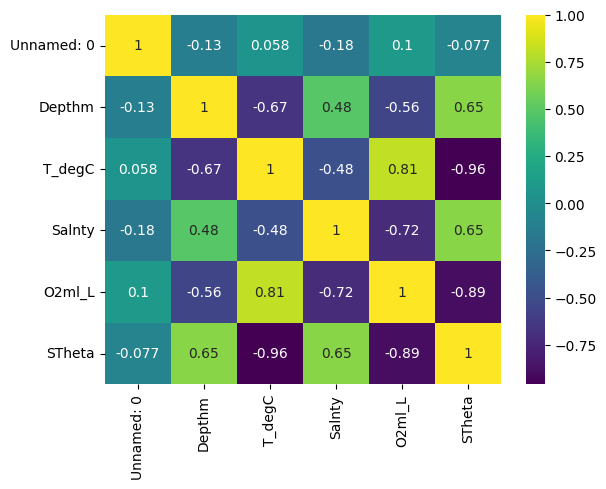

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
co_mtx = df.corr(numeric_only=True)

#Print correlation matrix
print(co_mtx)

#Plot correlation heatmap
sns.heatmap(co_mtx, cmap="viridis", annot=True)


# Display heatmap
plt.show()


<Axes: xlabel='STheta', ylabel='O2ml_L'>

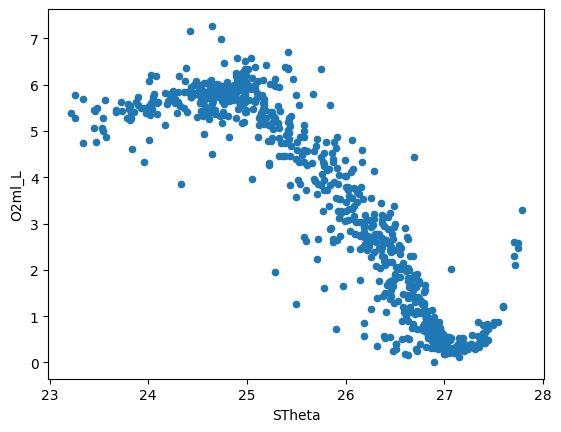

In [38]:
# Scatterplot O2ml_L (x) and Salnty (y)
df.plot.scatter(x="STheta", y="O2ml_L")

<Axes: xlabel='Salnty', ylabel='O2ml_L'>

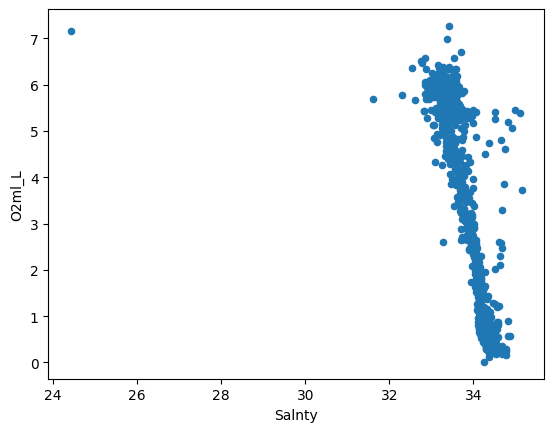

In [58]:
# Scatterplot O2ml_L (y) and Salnty (x)
df.plot.scatter(x="Salnty", y="O2ml_L")


<Axes: xlabel='T_degC', ylabel='O2ml_L'>

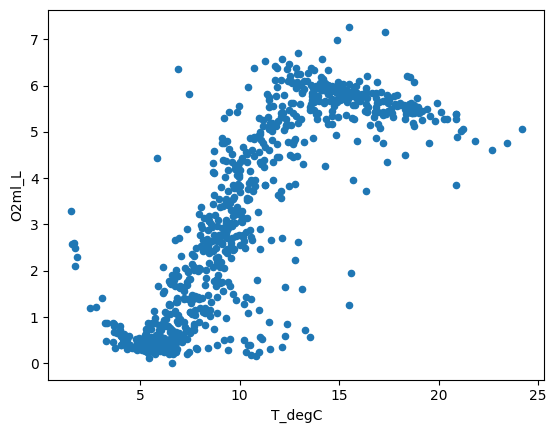

In [56]:
# Scatterplot O2ml_L (x) and T_degC (y)
df.plot.scatter(x="T_degC", y="O2ml_L")
#sns.regplot(x=df['T_degC'], y=df['O2ml_L'])

Creating The Model

Index(['Unnamed: 0', 'Depthm', 'T_degC', 'Salnty', 'STheta'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 29 to 102
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  800 non-null    int64  
 1   Depthm      800 non-null    int64  
 2   T_degC      800 non-null    float64
 3   Salnty      800 non-null    float64
 4   STheta      800 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 37.5 KB


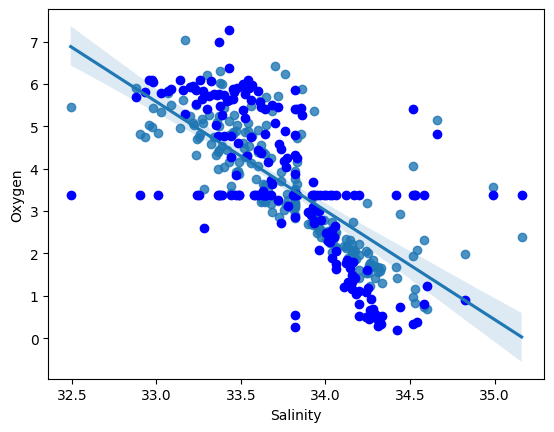

In [41]:
# `df` is called `filled_null_values`
#Create a linear regression model

from sklearn.model_selection import train_test_split


filled_null_values = filled_null_values.reset_index(drop=True)

model = LinearRegression()
y = filled_null_values["O2ml_L"]
x = filled_null_values.drop(["O2ml_L"], axis=1)
print(x.columns)
#x = filled_null_values[['Salnty']]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


X_train.info()


#Fit the model
model.fit(X_train, y_train)

# Make predictions
#y_pred = model.predict(filled_null_values['O2ml_L']) #.values.reshape(-1, 1))
y_pred = model.predict(X_test)
#print(y_pred)

# Plot the data and the regression line

sns.regplot(x=X_test['Salnty'], y=y_pred)
plt.scatter(X_test['Salnty'], y_test, color='blue')
#plt.plot(X_test['Salnty'], y_pred, color='red')
plt.xlabel('Salinity')
plt.ylabel('Oxygen')

plt.show()


In [42]:
# What is the correlation coefficient, r?
y_train.info()

#print(model.score(X_train, y_train))
#print('Correlation coefficient:', model.score(X_train, y_train))

<class 'pandas.core.series.Series'>
Index: 800 entries, 29 to 102
Series name: O2ml_L
Non-Null Count  Dtype  
--------------  -----  
800 non-null    float64
dtypes: float64(1)
memory usage: 12.5 KB


In [43]:
filled_null_values.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   Depthm      1000 non-null   int64  
 2   T_degC      1000 non-null   float64
 3   Salnty      1000 non-null   float64
 4   O2ml_L      1000 non-null   float64
 5   STheta      1000 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 47.0 KB


In [44]:
# What is the y-intercept?

print(f'Intercept: {model.intercept_}')

Intercept: 54.40283790276366


In [45]:
print(model.score(X_train, y_train))

0.6593555182796107


COMPARING MODELS

In [46]:
filled_null_values = filled_null_values.reset_index(drop=True)

x_simple = filled_null_values[['Salnty']]  # Keep ONLY Salinity
x_multi = filled_null_values.drop(["O2ml_L"], axis=1)  # ONLY drop Oxygen
y = filled_null_values["O2ml_L"]

# Split the data
# Simple regression
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    x_simple, y, test_size=0.2, random_state=42
)

# Multiple regression
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    x_multi, y, test_size=0.2, random_state=42
)

# Fit models
simple_regression = LinearRegression()
simple_regression.fit(X_train_simple, y_train_simple)

multi_regression = LinearRegression()
multi_regression.fit(X_train_multi, y_train_multi)

# Make predictions
y_pred_simple = simple_regression.predict(X_test_simple)
y_pred_multi = multi_regression.predict(X_test_multi)

Comparing Models

In [47]:
# Compare scores

print(f"Simple Regression Score: {simple_regression.score(X_test_simple, y_test_simple)}")
print(f'Multiple Regression Score: {multi_regression.score(X_test_multi, y_test_multi)}')

Simple Regression Score: 0.4433367069770049
Multiple Regression Score: 0.6647468007498379


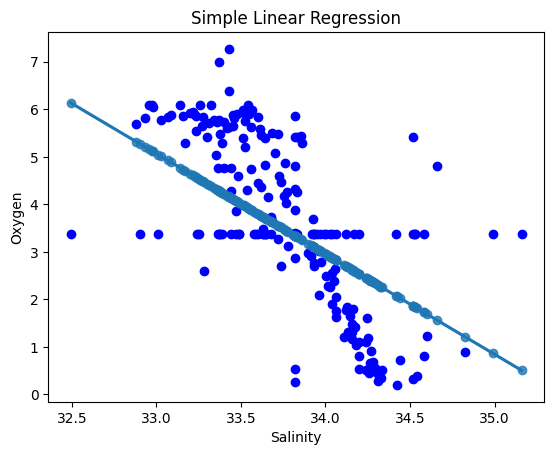

In [48]:


plt.scatter(X_test_simple['Salnty'], y_test_simple, color='blue')
sns.regplot(x=X_test_simple['Salnty'], y=y_pred_simple)
plt.xlabel('Salinity')
plt.ylabel('Oxygen')
plt.title('Simple Linear Regression')

plt.show()

/tmp/ipykernel_4236/4125332313.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


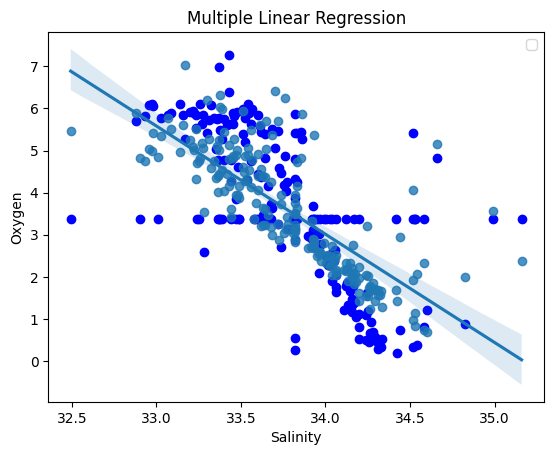

In [52]:
plt.scatter(X_test_multi[['Salnty']], y_test_multi, color='blue')
sns.regplot(x=X_test_multi['Salnty'], y=y_pred_multi)
plt.xlabel('Salinity')
plt.ylabel('Oxygen')
plt.title('Multiple Linear Regression')
plt.legend()

plt.show()